In [1]:
import os
os.chdir('../../../..')
print(os.getcwd())
from Simulation.libraries.SimulationLib.Environment import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import csv
from ExperimentTools.utils.ExperimentLogger import EpisodeLogger, EvaluationLogger, ShortestPath
import pickle
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

/Users/titonka/FAIRIS


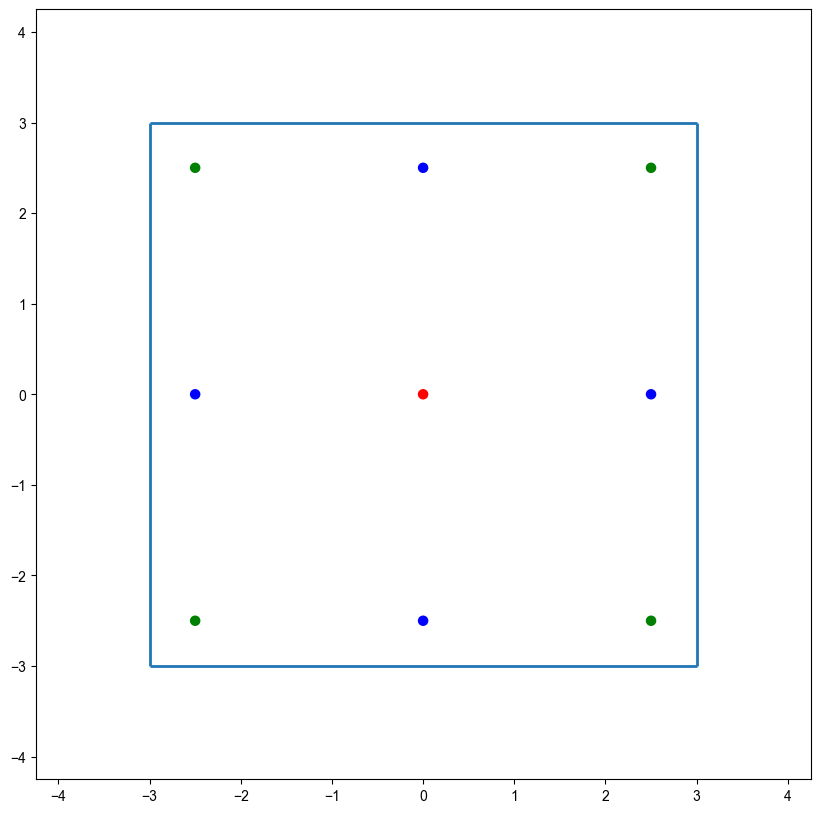

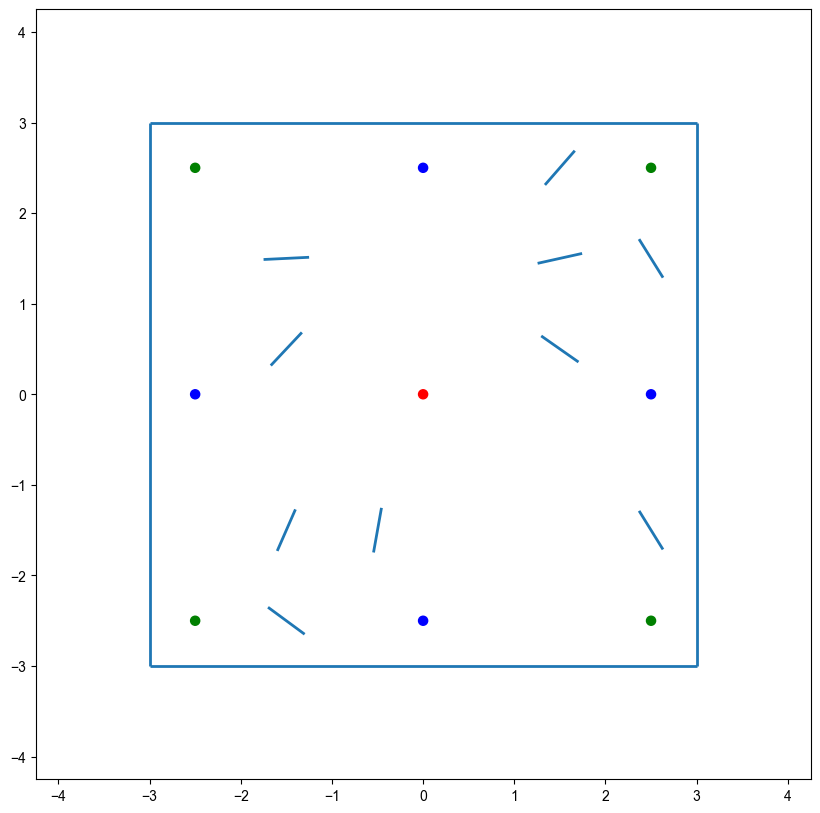

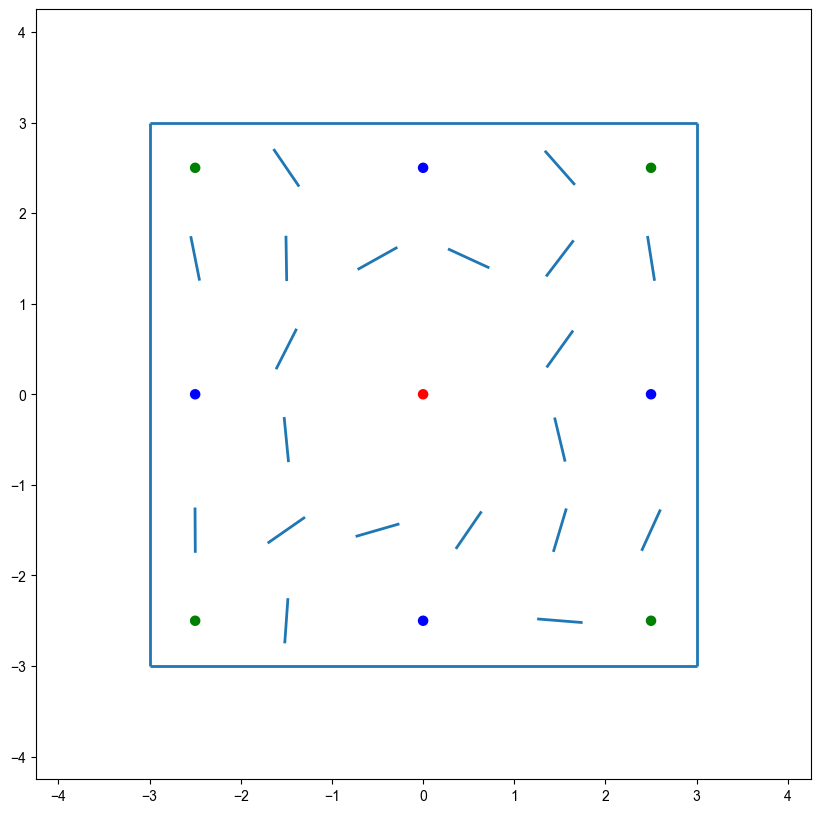

In [2]:
maze_files = ['WM00_paths.pkl','WM10_paths.pkl','WM20_paths.pkl']
mazes = []
for maze_file in maze_files:
    with open('Simulation/worlds/mazes/Experiment1/Paths/'+maze_file,'rb') as file:
        mazes.append(pickle.load(file))
def load_episodes_from_csv(filename):
    episodes = []
    with open(filename, 'r') as file:
        reader = csv.reader(file)
        current_episode = []
        
        for row in reader:
            if not row:  # Blank line signifies a new episode
                if current_episode:
                    episodes.append(current_episode)
                    current_episode = []
                continue
            
            # Convert row to a tuple of floats and add to the current episode
            current_episode.append(list(map(float, row)))
        
        if current_episode:  # Add the last episode if it exists
            episodes.append(current_episode)

    return episodes

def log_optimality_ratio(exp_data):
    maze_names = ['WM00','WM10','WM20']
    path_data = []
    name_index = 0
    for maze in mazes:
        starting_points = []
        path_lengths = []
        for path in maze.paths:
            starting_points.append(path.path[0])
            path_lengths.append(len(path.path)-1)
        path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
        name_index += 1
    
    path_metrics = {
        'WM00': path_data[0],
        'WM10': path_data[1],
        'WM20': path_data[2]
    }
    for experiment in exp_data:
        maze_ver = experiment.maze_file
        if maze_ver == 'WM00':
            data_index = 0
        elif maze_ver == 'WM10':
            data_index = 1
        shortest_path = path_metrics.get(maze_ver)
        for episode in experiment.episodes:
            start = (episode.path_xs[0] , episode.path_ys[0])
            min_dist = 100
            for s in shortest_path.starting_points:
                dist = math.sqrt((start[0] - s[0])**2 + (start[1]-s[1])**2)
                if dist < min_dist:
                    min_dist = dist
                    eps_start = s  
            min_length = int(shortest_path.path_lengths.get(eps_start))        
            optimality_ratio = (episode.path_length - min_length)/min_length
            experiment.log_optimality_ratio_of_paths(optimality_ratio)
            
maze_names = ['WM00','WM10','WM20']
path_data = []
name_index = 0
for maze in mazes:
    starting_points = []
    path_lengths = []
    for path in maze.paths:
        starting_points.append(path.path[0])
        path_lengths.append(len(path.path)-1)
    path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
    name_index += 1

path_metrics = {
    'WM00': path_data[0],
    'WM10': path_data[1],
    'WM20': path_data[2]
}

In [3]:
evaluation_data_PC = []
evaluation_data_No_PC = []
with open('logs/LargeScale/NoiseEval/AllPPOEvalData_PC_noise','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        evaluation_data_PC.append(EvaluationLogger(old_data=experiment))

with open('logs/LargeScale/NoiseEval/AllPPOEvalData_No_PC_noise','rb') as file:
    temp = pickle.load(file)
    for experiment in temp:
        evaluation_data_No_PC.append(EvaluationLogger(old_data=experiment))

log_optimality_ratio(evaluation_data_PC)
log_optimality_ratio(evaluation_data_No_PC)

In [4]:
def plot_optimality_ratio_boxplot(evaluation_data_PC, evaluation_data_no_PC):
    data = []

    # Process data from PC evaluation loggers
    for logger in evaluation_data_PC:
        world = 'WM00 (No Obstacles)' if 'WM00' in logger.maze_file else 'WM10 (10 Obstacles)'
        for ratio in logger.optimality_ratio_history:
            data.append({
                'Model': 'With Place Cells',
                'Noise Type and Level': f'{logger.noise_type} Level {logger.noise_level}',
                'Optimality Ratio': ratio,
                'World': world
            })

    # Process data from No PC evaluation loggers
    for logger in evaluation_data_no_PC:
        world = 'WM00 (No Obstacles)' if 'WM00' in logger.maze_file else 'WM10 (10 Obstacles)'
        for ratio in logger.optimality_ratio_history:
            data.append({
                'Model': 'Without Place Cells',
                'Noise Type and Level': f'{logger.noise_type} Level {logger.noise_level}',
                'Optimality Ratio': ratio,
                'World': world
            })

    # Create a DataFrame
    df = pd.DataFrame(data)

    # Set up the matplotlib figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

    # Function to create boxplot using seaborn
    def create_boxplot(ax, df, title):
        sns.boxplot(y='Noise Type and Level', x='Optimality Ratio', hue='Model', data=df, ax=ax, palette="Set2",showfliers=False)
        ax.set_title(title)
        ax.set_ylabel('Noise Type and Level')
        ax.set_xlabel('Optimality Ratio')
        ax.legend_.remove()

    # Create the boxplot for WM00
    create_boxplot(axes[0], df[df['World'] == 'WM00 (No Obstacles)'], 'Optimality Ratio Comparison for WM00 (No Obstacles)')

    # Create the boxplot for WM10
    create_boxplot(axes[1], df[df['World'] == 'WM10 (10 Obstacles)'], 'Optimality Ratio Comparison for WM10 (10 Obstacles)')

    # Create a single legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Adjust layout
    plt.tight_layout()
    plt.show()

    return df

def perform_significance_tests(df):
    results = []
    noise_levels = df['Noise Type and Level'].unique()
    
    for noise_level in noise_levels:
        for world in ['WM00 (No Obstacles)', 'WM10 (10 Obstacles)']:
            data_pc = df[(df['Noise Type and Level'] == noise_level) & (df['World'] == world) & (df['Model'] == 'With Place Cells')]['Optimality Ratio']
            data_no_pc = df[(df['Noise Type and Level'] == noise_level) & (df['World'] == world) & (df['Model'] == 'Without Place Cells')]['Optimality Ratio']
            
            # Perform Mann-Whitney U test
            stat, p_value = mannwhitneyu(data_pc, data_no_pc)
            pc_mean = data_pc.mean()
            no_pc_mean = data_no_pc.mean()
            
            results.append({
                'Noise Type and Level': noise_level,
                'World': world,
                'With PC Mean': pc_mean,
                'Without PC Mean': no_pc_mean,
                'Statistic': stat,
                'P-value': p_value,
                'Significant': p_value < 0.05,
                'With PC Better': p_value < 0.05 and pc_mean < no_pc_mean
            })

    results_df = pd.DataFrame(results)
    return results_df

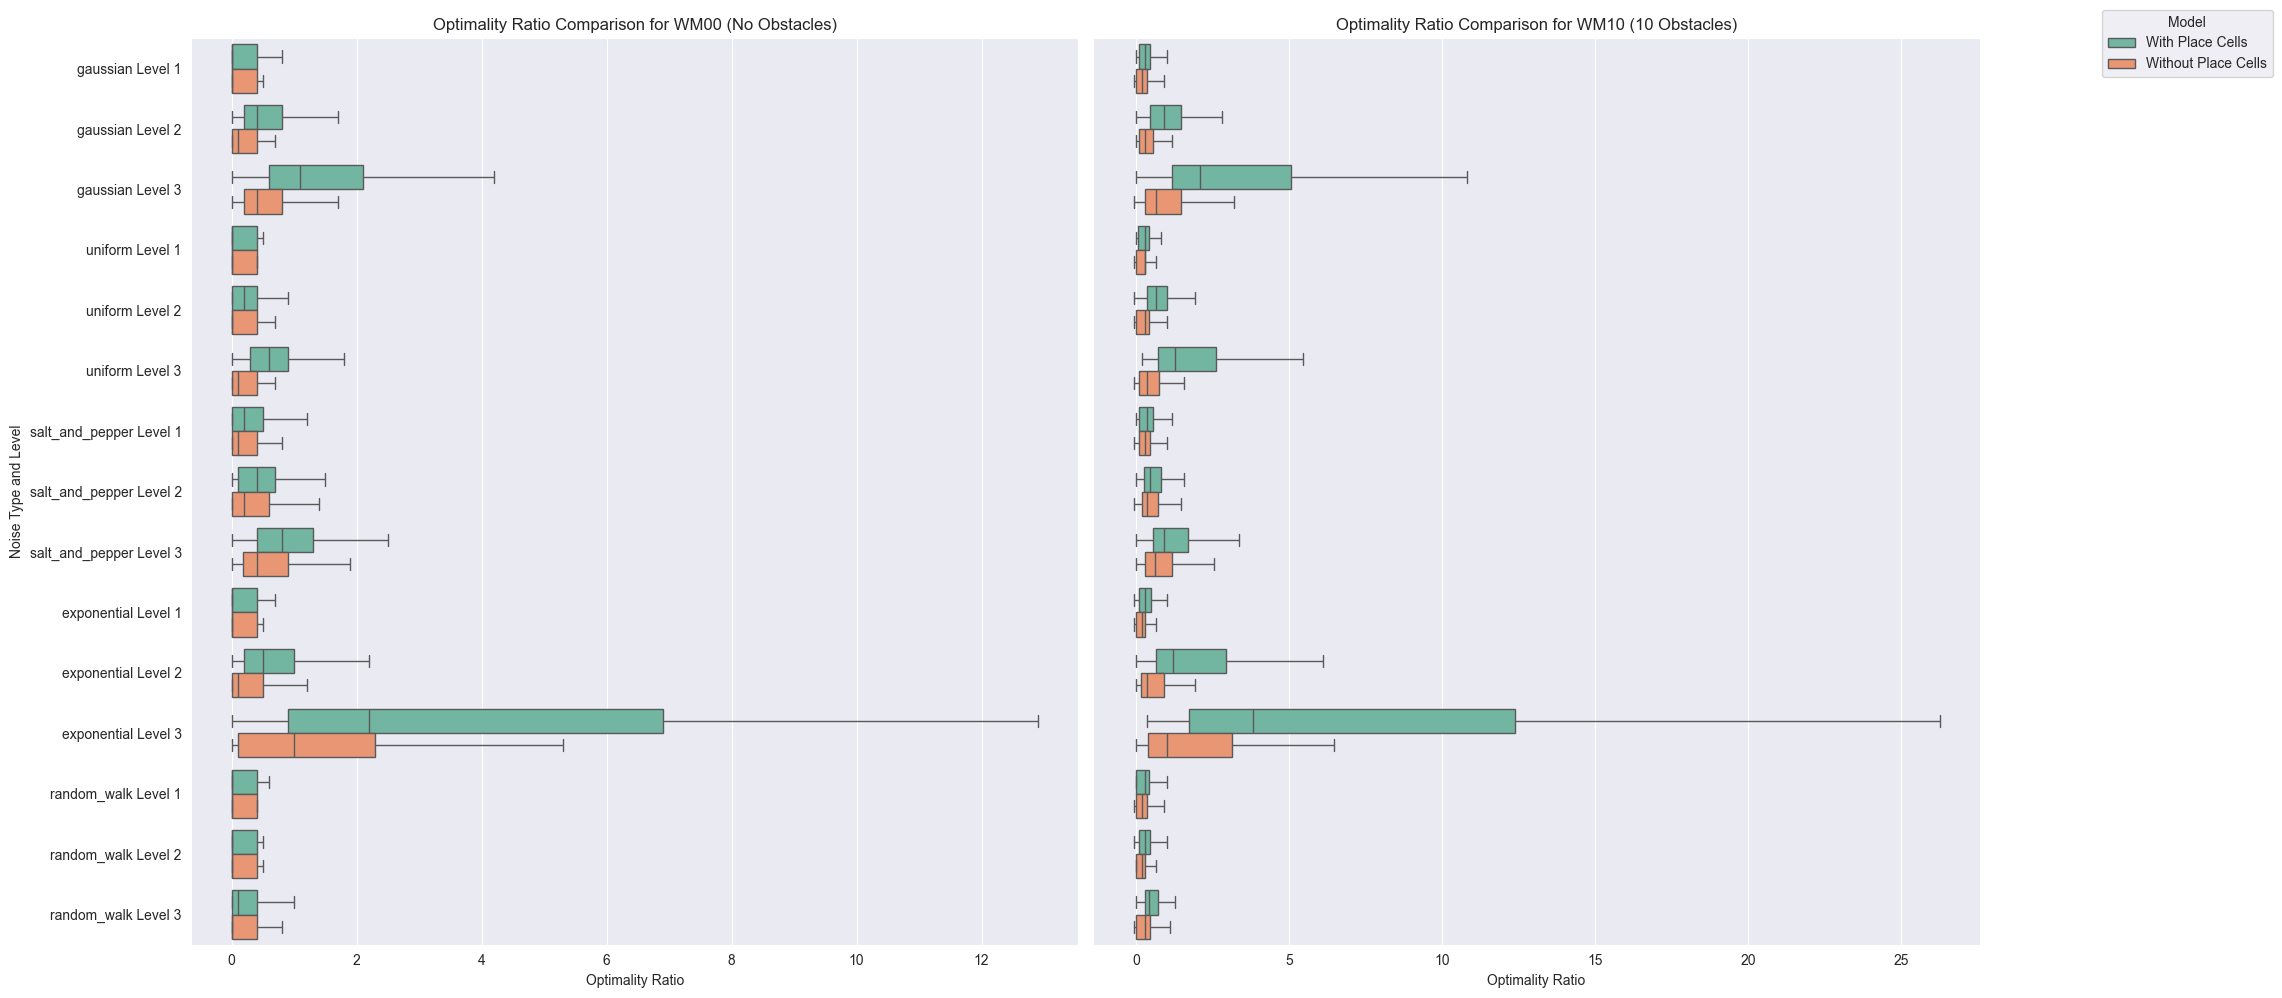

       Noise Type and Level                World  With PC Mean  \
0          gaussian Level 1  WM00 (No Obstacles)      0.201250   
1          gaussian Level 1  WM10 (10 Obstacles)      0.431307   
2          gaussian Level 2  WM00 (No Obstacles)      0.540000   
3          gaussian Level 2  WM10 (10 Obstacles)      1.229545   
4          gaussian Level 3  WM00 (No Obstacles)      1.731250   
5          gaussian Level 3  WM10 (10 Obstacles)      4.527557   
6           uniform Level 1  WM00 (No Obstacles)      0.178125   
7           uniform Level 1  WM10 (10 Obstacles)      0.475341   
8           uniform Level 2  WM00 (No Obstacles)      0.313125   
9           uniform Level 2  WM10 (10 Obstacles)      0.821818   
10          uniform Level 3  WM00 (No Obstacles)      0.713125   
11          uniform Level 3  WM10 (10 Obstacles)      2.333068   
12  salt_and_pepper Level 1  WM00 (No Obstacles)      0.311250   
13  salt_and_pepper Level 1  WM10 (10 Obstacles)      0.472330   
14  salt_a

In [5]:
from scipy.stats import ttest_ind, mannwhitneyu
df = plot_optimality_ratio_boxplot(evaluation_data_PC,evaluation_data_No_PC)
results_df = perform_significance_tests(df)
print(results_df)